In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch
import matplotlib.pyplot as plt
import torch.optim as optim
from torch import nn
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import dask.dataframe as dd

import numpy as np
import gc


from tsfresh import (
    extract_features,  
    select_features
)
from tsfresh.utilities.dataframe_functions import impute


from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBRegressor

from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV

In [ ]:

# Load and concatenate all features
file_prefix = "dataExt/P"
file_suffix = "_intensity.pkl"
num_files = 35

all_features = np.concatenate(
    [np.load(f"{file_prefix}{i:02d}{file_suffix}", allow_pickle=True) for i in range(num_files)],
    axis=0
)

old_label_arr = np.array([np.tile(i,np.load(f"{file_prefix}{0:02d}{file_suffix}", allow_pickle=True).shape[0]) for i in np.arange(num_files)]).flatten()

In [43]:
# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}

def check_duplicate_values(data_dict):
    values = list(data_dict.values())
    for i in range(len(values)):
        for j in range(i + 1, len(values)):
            if np.array_equal(values[i], values[j]):
                return True, (list(data_dict.keys())[i], list(data_dict.keys())[j])  # Return True and the keys
    return False, None

def convert_labels(old_labels):
    # Initialize a new array with shape (length of old labels, 3)
    new_labels = np.zeros((len(old_labels), 3), dtype=int)
    
    # Populate the new label array based on the mapping
    for i, label in enumerate(old_labels):
        new_labels[i] = class_to_poles[label]
    
    return new_labels

# Example usage:

new_label_arr = convert_labels(old_label_arr)

print("Old Labels:\n", old_label_arr)
print("New Labels:\n", new_label_arr)

Old Labels:
 [ 0  0  0 ... 34 34 34]
New Labels:
 [[0 0 0]
 [0 0 0]
 [0 0 0]
 ...
 [1 1 2]
 [1 1 2]
 [1 1 2]]


In [ ]:
gc.collect()
# Load data once
dask_df = dd.read_parquet('data/data_df.parquet')

# Extract features
extracted_features = extract_features(dask_df, column_id="id", column_sort="time",n_jobs=1, disable_progressbar=False).compute()

# Handle any NaNs
impute(extracted_features)

np.save('data/features_regression.npy', extracted_features.to_numpy())
gc.collect()

variable,feature__abs_energy,feature__absolute_maximum,feature__absolute_sum_of_changes,"feature__agg_autocorrelation__f_agg_""mean""__maxlag_40","feature__agg_autocorrelation__f_agg_""median""__maxlag_40","feature__agg_autocorrelation__f_agg_""var""__maxlag_40","feature__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""max""","feature__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""mean""","feature__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""min""","feature__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""var""",...,feature__symmetry_looking__r_0.9500000000000001,feature__time_reversal_asymmetry_statistic__lag_1,feature__time_reversal_asymmetry_statistic__lag_2,feature__time_reversal_asymmetry_statistic__lag_3,feature__value_count__value_-1,feature__value_count__value_0,feature__value_count__value_1,feature__variance,feature__variance_larger_than_standard_deviation,feature__variation_coefficient
id,,,,,,,,,,,,,,,,,,,,,
0,1.366759e+04,23.918039,31.698840,0.408902,0.418089,0.179896,22.663595,19.392079,16.016531,4.614539,...,1.0,-3.878319e+01,-9.674395e+01,-1.801483e+02,0.0,0.0,0.0,5.614541e+01,1.0,0.834981
1,1.553016e+04,25.935394,44.349551,0.138619,0.074365,0.325454,19.810890,16.191011,13.033462,5.346711,...,1.0,-1.048901e+00,-1.755551e+00,-2.157074e+00,0.0,0.0,0.0,6.528598e+01,1.0,0.851630
2,2.867975e+03,11.203798,19.230939,0.122892,0.049879,0.329015,8.378110,6.836979,5.446893,1.000022,...,1.0,-5.714397e-02,-6.180030e-02,-1.101976e-02,0.0,0.0,0.0,1.215478e+01,1.0,0.857636
3,4.167144e+04,43.422934,75.172240,0.084176,-0.009626,0.331067,30.626780,24.822289,19.408847,15.725694,...,1.0,1.750517e+00,1.199543e+01,3.180206e+01,0.0,0.0,0.0,1.808109e+02,1.0,0.875478
4,2.441234e+04,24.419825,27.135719,0.437924,0.510050,0.175845,4.322164,3.217947,1.941413,1.629511,...,1.0,8.680670e+01,1.785913e+02,2.759930e+02,0.0,0.0,0.0,5.801085e+01,1.0,0.558299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,6.594488e+03,20.485598,33.966174,-0.019661,-0.130338,0.296096,6.455342,5.681841,4.762355,1.355783,...,1.0,-1.514639e+00,-4.393932e+00,-7.792146e+00,0.0,0.0,0.0,1.869634e+01,1.0,0.629048
23996,1.860261e+05,111.959244,194.775368,0.013142,-0.050119,0.314281,30.655608,26.376577,21.757634,35.282181,...,1.0,-2.904348e+02,-7.350359e+02,-1.220344e+03,0.0,0.0,0.0,5.782400e+02,1.0,0.671593
23997,1.874118e+08,3321.007136,3999.064222,0.314733,0.251929,0.162396,-787.220459,-697.623596,-565.222770,-26745.286310,...,1.0,2.688172e+08,6.349339e+08,1.096198e+09,0.0,0.0,0.0,1.276319e+06,1.0,1.461175


In [4]:
features_regression = np.load('data/features_regression.npy', mmap_mode='r')
X_train_new, X_test_new, y_train, y_test = train_test_split(features_regression, new_label_arr,random_state=42)
X_train_old, X_test_old, _, _ = train_test_split(all_features, new_label_arr,random_state=42)

100%|██████████| 200/200 [32:16<00:00,  9.68s/it]


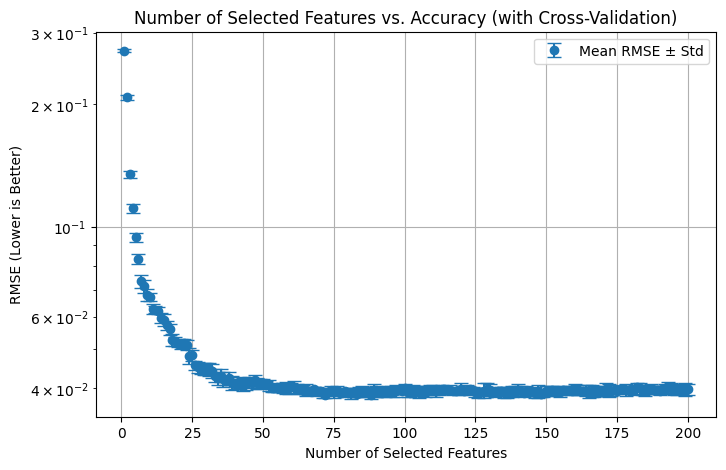

In [ ]:
# Train the initial model
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_new, y_train)

# Get feature importances
feature_importances = xgb_model.feature_importances_

# Sort importances and define thresholds
thresholds = np.sort(feature_importances)[::-1][:200]

# Define storage for results
num_features = []
rmse_means = []
rmse_stds = []

# Cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Loop through thresholds
for thresh in tqdm(thresholds):
    # Select features using the current threshold
    sfm = SelectFromModel(xgb_model, threshold=thresh, prefit=True)
    X_train_selected = sfm.transform(X_train_new)
    
    # Skip if no features are selected
    if X_train_selected.shape[1] == 0:
        continue
    
    # Store RMSE values for each fold
    fold_rmses = []
    
    for train_idx, val_idx in kf.split(X_train_selected):
        # Split into training and validation sets
        X_train_fold, X_val_fold = X_train_selected[train_idx], X_train_selected[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
        
        # Train model
        xgb_model_selected = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
        xgb_model_selected.fit(X_train_fold, y_train_fold)
        
        # Predict and calculate RMSE
        y_val_pred = xgb_model_selected.predict(X_val_fold)
        fold_rmse = mean_squared_error(y_val_fold, y_val_pred)  # RMSE
        fold_rmses.append(fold_rmse)
    
    # Store mean and std of RMSEs across folds
    num_features.append(X_train_selected.shape[1])
    rmse_means.append(np.mean(fold_rmses))
    rmse_stds.append(np.std(fold_rmses))

# Plot results
plt.figure(figsize=(8, 5))
plt.errorbar(num_features, rmse_means, yerr=rmse_stds, fmt='o', capsize=5, label='Mean RMSE ± Std')
plt.yscale("log")
plt.xlabel("Number of Selected Features")
plt.ylabel("RMSE (Lower is Better)")
plt.title("Number of Selected Features vs. Accuracy (with Cross-Validation)")
plt.grid()
plt.legend()
plt.show()


In [ ]:
# np.float32(0.0009535997)
xgb_model = XGBRegressor(random_state=42)
sfm = SelectFromModel(xgb_model, threshold=0.000953599)
sfm.fit(features_regression,new_label_arr)
features_regression_selected = sfm.transform(features_regression)
np.save('data/features_regression_selected.npy', features_regression_selected)

In [6]:
features_regression_selected = np.load('data/features_regression_selected.npy', mmap_mode='r')
X_train_new, X_test_new, y_train, y_test = train_test_split(features_regression_selected, new_label_arr,random_state=42)
X_train_old, X_test_old, _, _ = train_test_split(all_features, new_label_arr,random_state=42)

# Option 1: Multiple Submodels

In [55]:
model_new = MultiOutputRegressor(
  estimator = HistGradientBoostingRegressor()
)

model_old = MultiOutputRegressor(
  estimator = HistGradientBoostingRegressor()
)

cv_submodel_new = cross_validate(model_new, X_train_new, y_train, cv=5, scoring='neg_mean_squared_error', return_estimator=True)
cv_submodel_old = cross_validate(model_old, X_train_old, y_train, cv=5, scoring='neg_mean_squared_error', return_estimator=True)


res_arr = np.zeros(5)
for cnt,est in enumerate(cv_submodel_new["estimator"]):
    res_arr[cnt] = np.sum(np.sum(np.round(est.predict(X_test_new)) == y_test,axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy New: {np.mean(res_arr):.4f} ± {np.std(res_arr):.4f}")

res_arr = np.zeros(5)
for cnt,est in enumerate(cv_submodel_old["estimator"]):
    res_arr[cnt] = np.sum(np.sum(np.round(est.predict(X_test_old)) == y_test,axis=1) == 3)/y_test.shape[0]

print(f"Test Accuracy Old: {np.mean(res_arr):.4f} ± {np.std(res_arr):.4f}")

Test Accuracy New: 0.8759 ± 0.0020
Test Accuracy Old: 0.6739 ± 0.0047


# Option 2: One model multi output

In [ ]:
# Define the model
model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Define the parameter grid with a well-balanced search space
param_grid = {
    'learning_rate': np.logspace(-3, 0, 10),      # Learning rates between 0.001 and 1
    'n_estimators': [50, 100, 200, 300],          # Number of boosting rounds
    'max_depth': [3, 5, 7, 10],                   # Maximum depth of trees
    'min_child_weight': [1, 3, 5, 10],            # Minimum sum of weights of all children
    'subsample': [0.6, 0.8, 1.0],                 # Subsample ratio of training instances
    'colsample_bytree': [0.6, 0.8, 1.0],          # Subsample ratio of features per tree
    'reg_alpha': np.logspace(-3, 1, 5),           # L1 regularization strength
    'reg_lambda': np.logspace(-3, 1, 5)           # L2 regularization strength
}

# Define the Halving Random Search with cross-validation
halving_search = HalvingRandomSearchCV(
    estimator=model,
    param_distributions=param_grid,
    factor=2,                        # Halving factor: reduce candidate configurations by half
    cv=5,                            # 5-fold cross-validation
    scoring='neg_mean_squared_error', # Use RMSE as evaluation metric (negative since higher scores are better)
    random_state=42,
    n_jobs=-1,                       # Use all available CPU cores
    verbose=1                        # Increase verbosity for better monitoring
)

# Perform the halving search
halving_search.fit(X_train_new, y_train)

# Print the best parameters and score
print("Best parameters found: ", halving_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(halving_search.best_score_))

# Evaluate the best model on the test set
best_model = halving_search.best_estimator_

In [10]:
model_new = XGBRegressor(**{'subsample': 0.6, 'reg_lambda': np.float64(0.1), 'reg_alpha': np.float64(1.0), 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': np.float64(0.046415888336127774), 'colsample_bytree': 0.6})
model_old = XGBRegressor()

cv_submodel_new = cross_validate(model_new, X_train_new, y_train, cv=5, scoring='neg_mean_squared_error', return_estimator=True)
cv_submodel_old = cross_validate(model_old, X_train_old, y_train, cv=5, scoring='neg_mean_squared_error', return_estimator=True)

res_arr = np.zeros(5)
for cnt,est in enumerate(cv_submodel_new["estimator"]):
    res_arr[cnt] = np.sum(np.sum(np.round(est.predict(X_test_new)) == y_test,axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy New: {np.mean(res_arr):.4f} ± {np.std(res_arr):.4f}")

res_arr = np.zeros(5)
for cnt,est in enumerate(cv_submodel_old["estimator"]):
    res_arr[cnt] = np.sum(np.sum(np.round(est.predict(X_test_old)) == y_test,axis=1) == 3)/y_test.shape[0]

print(f"Test Accuracy Old: {np.mean(res_arr):.4f} ± {np.std(res_arr):.4f}")

Test Accuracy New: 0.8972 ± 0.0018
Test Accuracy Old: 0.7212 ± 0.0019


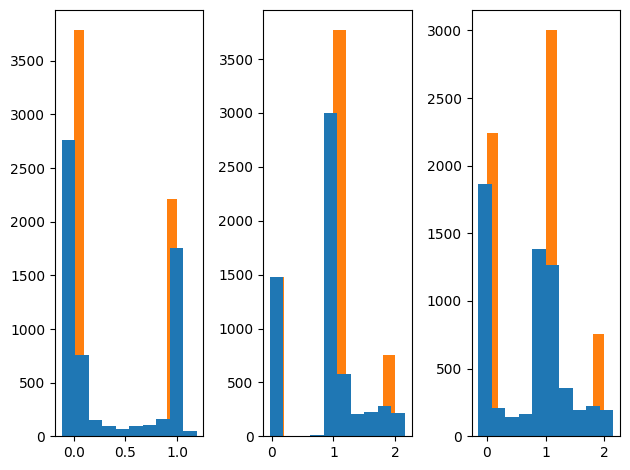

In [13]:
fig, axs = plt.subplots(1,3)

axs[0].hist(cv_submodel_new['estimator'][0].predict(X_test_new)[:,0])
axs[0].hist(y_test[:,0],zorder=0)

axs[1].hist(cv_submodel_new['estimator'][0].predict(X_test_new)[:,1])
axs[1].hist(y_test[:,1],zorder=0)

axs[2].hist(cv_submodel_new['estimator'][0].predict(X_test_new)[:,2])
axs[2].hist(y_test[:,2],zorder=0)

fig.tight_layout()

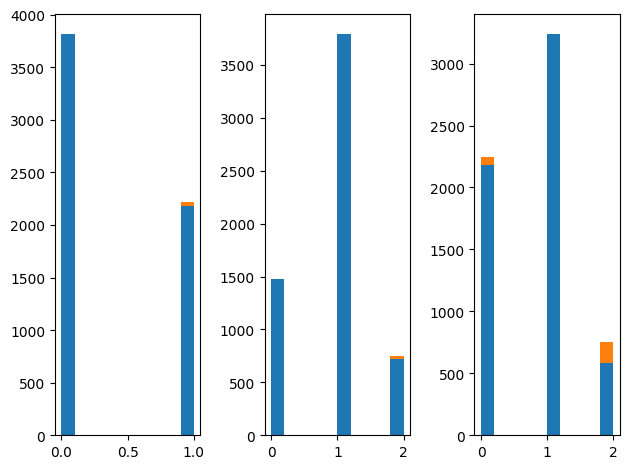

In [14]:
fig, axs = plt.subplots(1,3)

axs[0].hist(np.round(cv_submodel_new['estimator'][0].predict(X_test_new)[:,0]))
axs[0].hist(y_test[:,0],zorder=0)

axs[1].hist(np.round(cv_submodel_new['estimator'][0].predict(X_test_new)[:,1]))
axs[1].hist(y_test[:,1],zorder=0)

axs[2].hist(np.round(cv_submodel_new['estimator'][0].predict(X_test_new)[:,2]))
axs[2].hist(y_test[:,2],zorder=0)

fig.tight_layout()

# Option 3: Multi NN approach

In [59]:
class PoleDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]


scaler = StandardScaler()
features_memmap_scaled = scaler.fit_transform(features_regression_selected)
X_train_new, X_test_new, y_train, y_test = train_test_split(features_memmap_scaled, new_label_arr)

scaler = StandardScaler()
features_all_scaled = scaler.fit_transform(all_features)
X_train_old, X_test_old, _, _ = train_test_split(features_all_scaled, new_label_arr)


# Create Dataset objects
train_dataset = PoleDataset(X_train_new, y_train)
test_dataset = PoleDataset(X_test_new, y_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [61]:
# Define the neural network model
class PoleRegression(nn.Module):
    def __init__(self, input_size=143, hidden_size=100):
        super(PoleRegression, self).__init__()
        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, 3)  # Output size of 3 for regression targets

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.output(x)

# Initialize model, loss function, and optimizer
model = PoleRegression()
criterion = nn.MSELoss()  # MSE Loss for regression
optimizer = optim.Adam(model.parameters(), lr=0.00001)

num_epochs = 1000
train_losses = []
test_losses = []

patience = 10  # Number of epochs to wait for improvement
min_delta = 1e-4  # Minimum change to qualify as an improvement
best_test_loss = float('inf')  # Initialize best test loss as infinity
patience_counter = 0  # Counter to track epochs without improvement

# Training loop with early stopping
for epoch in range(num_epochs):
    # Train phase
    model.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()  # Reset gradients
        outputs = model(inputs)  # Get model predictions
        loss = criterion(outputs, targets)  # Calculate MSE loss
        loss.backward()  # Backpropagate the loss
        optimizer.step()  # Update the model weights
        
        train_loss += loss.item()  # Accumulate loss for tracking
    
    # Average training loss for this epoch
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Test phase (evaluate model on validation/test data)
    model.eval()
    test_loss = 0.0
    with torch.no_grad():  # No need to track gradients for evaluation
        for inputs, targets in test_loader:
            outputs = model(inputs)  # Get model predictions
            loss = criterion(outputs, targets)  # Calculate MSE loss
            test_loss += loss.item()  # Accumulate loss for tracking
    
    # Average test loss for this epoch
    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    
    # Print epoch stats every 10 epochs
    if epoch % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')
    
    # Early stopping check
    if test_loss < best_test_loss - min_delta:
        best_test_loss = test_loss
        patience_counter = 0  # Reset counter if test loss improves
    else:
        patience_counter += 1  # Increment counter if no improvement
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1} with best test loss: {best_test_loss:.4f}")
        break


Epoch [1/1000], Train Loss: 0.7528, Test Loss: 0.6636
Epoch [11/1000], Train Loss: 0.1934, Test Loss: 0.1863
Epoch [21/1000], Train Loss: 0.1407, Test Loss: 0.1384
Epoch [31/1000], Train Loss: 0.1170, Test Loss: 0.1167
Epoch [41/1000], Train Loss: 0.1049, Test Loss: 0.1054
Epoch [51/1000], Train Loss: 0.0966, Test Loss: 0.0982
Epoch [61/1000], Train Loss: 0.0906, Test Loss: 0.0929
Epoch [71/1000], Train Loss: 0.0858, Test Loss: 0.0890
Epoch [81/1000], Train Loss: 0.0818, Test Loss: 0.0857
Epoch [91/1000], Train Loss: 0.0786, Test Loss: 0.0830
Epoch [101/1000], Train Loss: 0.0756, Test Loss: 0.0805
Epoch [111/1000], Train Loss: 0.0733, Test Loss: 0.0785
Epoch [121/1000], Train Loss: 0.0712, Test Loss: 0.0767
Epoch [131/1000], Train Loss: 0.0693, Test Loss: 0.0750
Epoch [141/1000], Train Loss: 0.0673, Test Loss: 0.0736
Epoch [151/1000], Train Loss: 0.0658, Test Loss: 0.0724
Epoch [161/1000], Train Loss: 0.0642, Test Loss: 0.0714
Epoch [171/1000], Train Loss: 0.0628, Test Loss: 0.0702
Epo

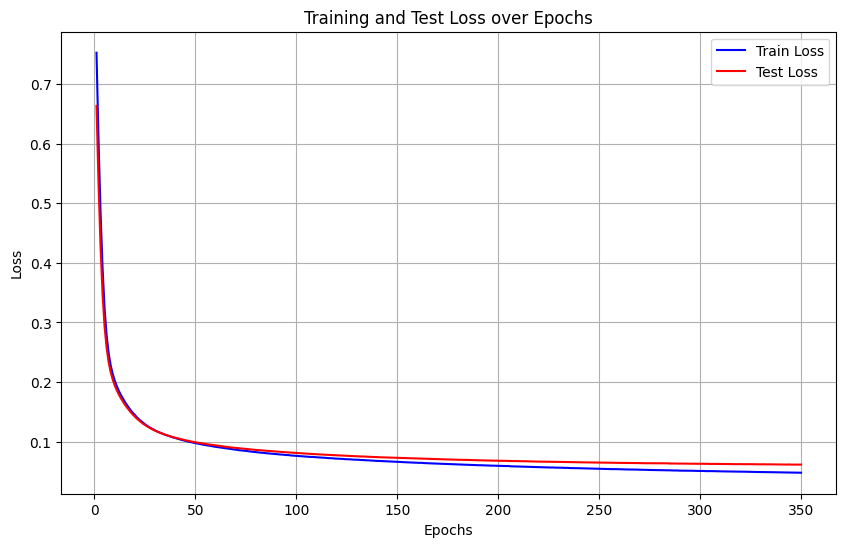

In [62]:
# Plot train and test loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, epoch +2), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, epoch +2), test_losses, label='Test Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)

# plt.yscale("log")
# plt.ylim(0,0.5)
plt.show()

In [63]:
model.eval()

acc_arr = []
with torch.no_grad():  # No need to track gradients for evaluation
    for inputs, targets in test_loader:
        outputs = model(inputs)  # Get model predictions
        acc_arr.append(torch.sum(torch.sum(np.round(outputs) == targets,axis=1) == 3)/targets.shape[0])
np.mean(acc_arr)

np.float32(0.847019)

In [ ]:
# class PoleClassifier(nn.Module):
#     def __init__(self, input_size=100, hidden_size=100):
#         super(PoleClassifier, self).__init__()
#         # Define layers
#         self.fc1 = nn.Linear(input_size, hidden_size)
#         self.fc2 = nn.Linear(hidden_size, hidden_size)
        
#         # Outputs for binary presence of poles on each position
#         self.presence_bt = nn.Linear(hidden_size, 1)  # Binary presence for [bt]
#         self.presence_bb = nn.Linear(hidden_size, 1)  # Binary presence for [bb]
#         self.presence_tb = nn.Linear(hidden_size, 1)  # Binary presence for [tb]
        
#         # Outputs for count of poles at each position
#         self.count_bt = nn.Linear(hidden_size, 1)     # Count of poles on [bt]
#         self.count_bb = nn.Linear(hidden_size, 1)     # Count of poles on [bb]
#         self.count_tb = nn.Linear(hidden_size, 1)     # Count of poles on [tb]
        
#     def forward(self, x):
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
        
#         # Presence predictions (binary)
#         presence_bt = torch.sigmoid(self.presence_bt(x))
#         presence_bb = torch.sigmoid(self.presence_bb(x))
#         presence_tb = torch.sigmoid(self.presence_tb(x))
        
#         # Count predictions (continuous)
#         count_bt = F.relu(self.count_bt(x))
#         count_bb = F.relu(self.count_bb(x))
#         count_tb = F.relu(self.count_tb(x))
        
#         return torch.concatenate([presence_bt,
#                 presence_bb,
#                 presence_tb,
#                 count_bt,
#                 count_bb,
#                 count_tb],dim=1)


# # Custom loss function combining binary cross-entropy (for presence) and MSE (for counts)
# class CustomLoss(nn.Module):
#     def __init__(self):
#         super(CustomLoss, self).__init__()
    
#     def forward(self, outputs, targets):

#         # Split outputs and targets into presence and count parts
#         pred_presence = outputs[:, :3]  # Presence predictions (bt, bb, tb)
#         pred_counts = outputs[:, 3:]    # Count predictions (bt, bb, tb)

#         target_presence = targets[:, :3]  # Presence targets
#         target_counts = targets[:, 3:]    # Count targets

#         # Binary Cross-Entropy for presence
#         presence_loss = nn.BCEWithLogitsLoss()(pred_presence, target_presence)
        
#         # Mean Squared Error for counts
#         count_loss = nn.MSELoss()(pred_counts, target_counts)

#         # Total loss (combining both)
#         total_loss = presence_loss + count_loss
#         return total_loss

In [ ]:
fig,axs = plt.subplots(1,2,figsize=(5,5))

axs[0].imshow(targets)
axs[1].imshow(np.round(outputs.numpy() ))

fig.tight_layout()

In [ ]:
import torch

def get_class_from_output(outputs):
    # Round the outputs
    presence_bt, presence_bb, presence_tb = np.round(outputs[0].numpy()), np.round(outputs[1].numpy()), np.round(outputs[2].numpy())
    count_bt, count_bb, count_tb = np.round(outputs[3].numpy()), np.round(outputs[4].numpy()), np.round(outputs[5].numpy())

    # Map the rounded output to a class (0-7)
    class_mapping = {
        (1, 0, 0, 0, 0, 0): 0,  # Presence: bt, count: bt = 0
        (0, 1, 0, 0, 0, 0): 1,  # Presence: bb, count: bb = 0
        (0, 0, 1, 0, 0, 0): 2,  # Presence: tb, count: tb = 0
        (1, 1, 0, 1, 0, 0): 3,  # Presence: bt + bb, count: bt = 1
        (1, 0, 1, 0, 1, 0): 4,  # Presence: bt + tb, count: bb = 1
        (0, 1, 1, 0, 1, 0): 5,  # Presence: bb + tb, count: bb = 1
        (1, 1, 1, 1, 1, 0): 6,  # Presence: bt + bb + tb, count: bt = 1
        (1, 0, 0, 2, 0, 0): 7   # Presence: bt, count: bt = 2
    }
    
    # Map the rounded values to the class label
    class_label = class_mapping.get((presence_bt, presence_bb, presence_tb, count_bt, count_bb, count_tb), -1)

    print(presence_bt, presence_bb, presence_tb, count_bt, count_bb, count_tb, class_label)
    return class_label

def convert_to_class_matrix(outputs):
    """
    Given the outputs for a batch of samples, convert them to the class matrix
    where each row corresponds to the class of a sample.
    """
    class_labels = []

    for output in outputs:
        class_label = get_class_from_output(output)
        class_labels.append(class_label)
    
    return torch.tensor(class_labels)



class_matrix = convert_to_class_matrix(outputs)
print(class_matrix)  # This will give the class labels for each sample in the batch.


In [ ]:
def get_class_from_output(outputs):
    # Convert outputs into a tuple of presence and count
    presence_bt, presence_bb, presence_tb = outputs[:,0], outputs[:,1], outputs[:,2]
    count_bt, count_bb, count_tb = outputs[:,3], outputs[:,4], outputs[:,5]
    
    # Convert continuous count values into discrete values (e.g., rounding)
    count_bt = np.round(count_bt.numpy())
    count_bb = np.round(count_bb.numpy())
    count_tb = np.round(count_tb.numpy())
    
    # Convert presence to binary (0 or 1)
    presence_bt = np.round(presence_bt.numpy())
    presence_bb = np.round(presence_bb.numpy())
    presence_tb = np.round(presence_tb.numpy())
    
    # Create a tuple of (presence_bt, presence_bb, presence_tb, count_bt, count_bb, count_tb)
    # We map this tuple into a class index
    class_mapping = {
        (1, 0, 0, 1, 0, 0): 0,  # Class 0
        (0, 1, 0, 0, 1, 0): 1,  # Class 1
        (0, 0, 1, 0, 0, 1): 2,  # Class 2
        (1, 1, 0, 1, 1, 0): 3,  # Class 3
        (0, 1, 1, 0, 1, 1): 4,  # Class 4
        (1, 1, 1, 1, 1, 1): 5,  # Class 5
        (0, 2, 0, 0, 2, 0): 6,  # Class 6
        (0, 1, 2, 0, 1, 2): 7   # Class 7
    }
    
    return class_mapping.get((presence_bt, presence_bb, presence_tb, count_bt, count_bb, count_tb), -1)  # -1 if no match
get_class_from_output(outputs)